# Autocorrelation Phase Matrix

Which are the weaknesses of autocorrelation-based tempogram?

It assumes that beats are always equally spaced.

What if:
* Beat can shift in **time** (e.g., between different levels of the metrical hierarchy) 
* Beat can shift in **phase** (e.g., from unsyncopated to syncopated)
* Beat can **change** in the middle of a piece (e.g., when the meter and tempo shifts are encountered)
* Polyrhythms are present (hemiola, cross-rhythm, etc.) ?

An ideal beat estimation process should consider multiple hypotheses about beat in parallel and should be able to switch between these hypotheses.

# Autocorrelation Phase Matrix

Let's consider again a given **windowed** novelty function of **finite length** $N$ $\Delta_{w,n}(m):\mathbb{Z}\to\mathbb{R}$, defined as for the autocorrelation tempogram.


For notation simplicity, let's discard $n$ and $w$ parameters (window index and window type parameter) and consider just one window of length $N$ of the novelty function, which we will indicate as $\Delta(m)$. The length of the windowed signal $N$ must be long enough for analyzing all the possible tempos 
\begin{equation}
    1\leq  k_{\text{min}} \leq k_{\text{max}} \leq N-1.
\end{equation}


Then, the **Autocorrelation Phase Matrix (APM)** will be defined as 

\begin{equation}
P(\phi, k) = \sum_{i=0}^{\lceil\frac{N -\phi}{k}\rceil} \Delta(k i + \phi)\Delta(k(i+1)+\phi)
\end{equation}

where $k$ is the considered lag and $\phi$ is the phase.

Phase is constrained such that $\phi < k$, hence APM is a **triangular matrix**.

For each lag $k$ of interest, the APM stores intermediate results of autocorrelation in a vector of length $k$ such that the results of the autocorrelation dot product are wrapped into the APM row according to their phase $\phi$. In this way, APM preserves the distribution of autocorrelation energy in the **phase space**.


Let's see an example:

<img src="data/img/apm_1.png" width="800px" align="center" alt="APM first example">
<img src="data/img/apm_2.png" width="800px" align="center" alt="APM second example">
<img src="data/img/apm_3.png" width="800px" align="center" alt="APM third example">


Let's define also a counter matrix $C$ that allows us to "normalize" the APM:

\begin{equation}
C(\phi, k)=\frac{N-\phi}{k}
\end{equation}

Hence, unbiased APM can be obtained as element-wise division of $P(\phi, k)$ by $C(\phi, k)$: 


\begin{equation}
\hat{P}(\phi, k) = \frac{P(\phi, k)}{C(\phi, k)}
\end{equation}



The algorithm can be expressed in pseudocode as:


<img src="data/img/pseudocode.png" width="800px" align="left" alt="Pseudocode for APM computation">



### Autocorrelation from APM

Autocorrelation for a window $a(k)$ can be obtained by summing all phase values for each lag, i.e., summing the rows of the APM $P(k, \phi)$.

\begin{equation}
\mathcal{A}(k) = \sum_{i=0}^{k-1} P(k, i)
\end{equation}




<h1> Implementation </h1>

In [1]:
import numpy as np
import librosa
import os
import matplotlib.pyplot as plt

Let's define a **novelty function** (it's different from the novelty functions we analyzed in class, so let's skip this)

In [2]:
def a_novelty_function(x, Fs=1, N=1024, H=512, norm=1):
    """Compute complex-domain novelty function
    """     
    X = librosa.stft(x, n_fft=N, hop_length=H, win_length=N, window='hann')
    Fs_feature = Fs/H
    mag = np.abs(X)
    
    phase = np.angle(X)/(2*np.pi)
    
    unwr_phase = np.zeros_like(X, dtype=float);
    for i in np.arange(X.shape[1]):
        unwr_phase[:,i] = np.unwrap( np.angle(X[:,i]) )
    
    def warp(x, low, interval):
        return np.remainder(x - low, interval) + low
    
    phase_shift = unwr_phase[:,2:] - 2*unwr_phase[:,1:-1] + unwr_phase[:,0:-2]
    phase_shift =  warp(phase_shift, -np.pi, 2*np.pi)
    
    
    amp_pred = mag[:,1:-1]
    amp_true = mag[:,2:]
    
    novelty_complex = (amp_pred**2 + amp_true**2 - 2 * amp_pred * amp_true * np.cos(phase_shift))
    
    # Half wave rectification
    novelty_complex[novelty_complex<0]=0
    
    novelty_complex = np.sqrt(novelty_complex)
    
    novelty_complex = np.sum(novelty_complex, axis=0)
    novelty_complex = np.concatenate((novelty_complex, np.array([0, 0])))
    
    if norm == 1:
        max_value = max(novelty_complex)
        if max_value > 0:
            novelty_complex = novelty_complex / max_value
        
    return novelty_complex, Fs_feature


### Compute Novelty Function

In [3]:
fn_wav = 'data/audio/Beatles.wav'
Fs = 22050
x, Fs = librosa.load(fn_wav, sr=Fs)


nov, Fs_nov = a_novelty_function(x, Fs=Fs, N=1024, H=512)


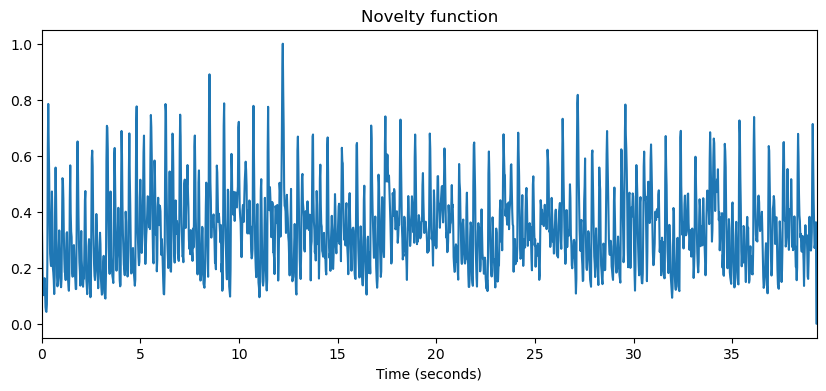

In [4]:
feature_time_axis = np.arange(nov.shape[0]) / Fs_nov

plt.figure(figsize=(10, 4))
plt.xlim([feature_time_axis[0], feature_time_axis[-1]])
plt.title('Novelty function')
plt.xlabel('Time (seconds)')
plt.plot(feature_time_axis, nov)
plt.show()

### Compute APM

In [5]:
def compute_APM(x, lags):
    N = len(x)
    n_lags = len(lags)
    max_lag = lags[-1]                   # the maximum lag
    
    P = np.zeros((n_lags, max_lag))
    C = np.zeros((n_lags, max_lag))
    
    # for all the lags k
    for lag_index in np.arange(n_lags):
        k = lags[lag_index]             # period
        # for all the phases phi 
        for phi in np.arange(k):
            # compute how many elements we need to sum = number of samples with stride k and phase phi in a N-long sequence
            n = np.ceil(( N-phi)/k)                       
            i = np.array(phi + k*np.arange(n), dtype=int)       # indices of those samples
            P[lag_index,phi] = np.sum(x[i[:-1]] * x[i[1:]])     # multiply and add
            C[lag_index,phi] = n - 1                            # counter matrix, for unbiased ac = number of elements for each pair (k, phi)
    C[C==0]=1 # to avoid dividing by zero 

    return P, C

In [6]:
k_min = 20
k_max = 128
lag_interval = np.arange(k_min, k_max)
time_interval = np.arange(512, 1024)

P, C = compute_APM(nov[time_interval], lag_interval)

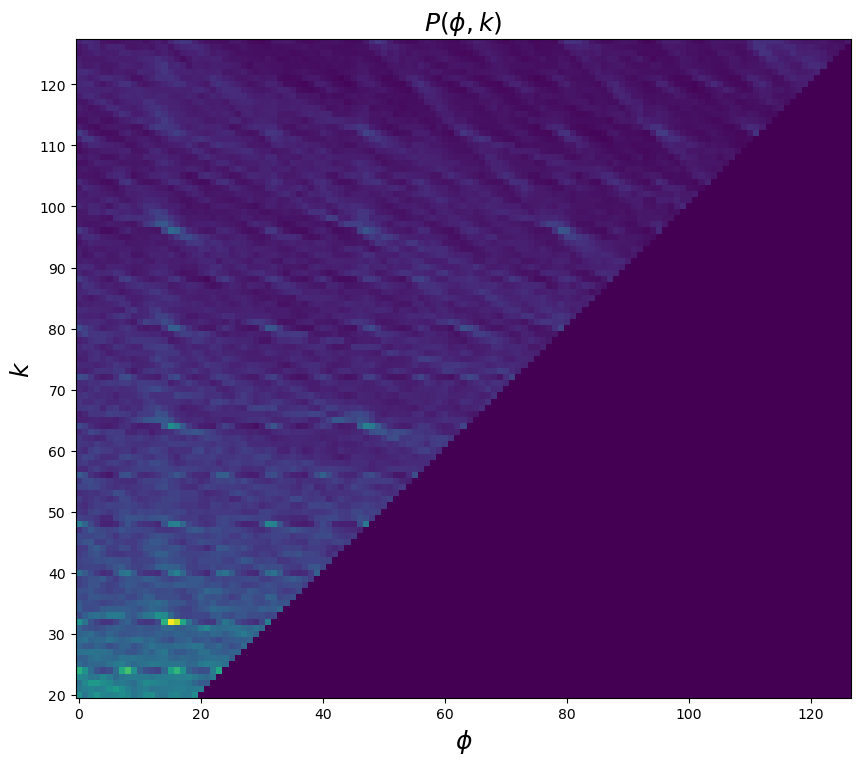

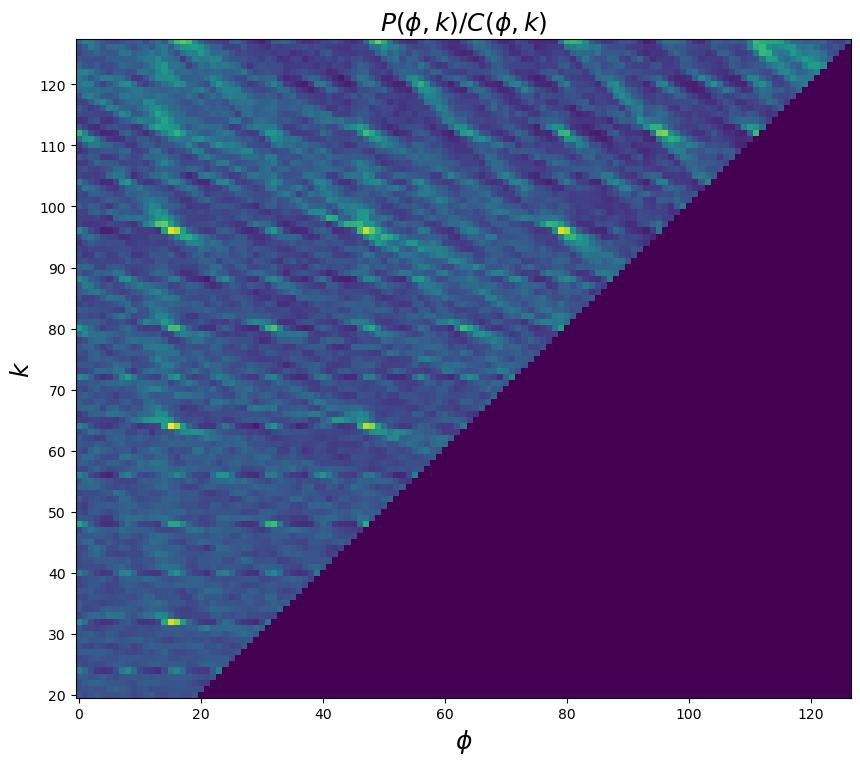

In [7]:
plt.figure(figsize=(10, 10))
plt.imshow(P, origin='lower')

plt.xlabel(r'$\phi$', fontsize=18)
plt.ylabel(r'$k$', fontsize=18)
plt.yticks(np.arange(0, k_max - k_min, 10), lag_interval[::10])
plt.title(r'$P(\phi, k)$', fontsize=18)

plt.figure(figsize=(10, 10))
plt.imshow(P/C,origin='lower')
plt.xlabel(r'$\phi$', fontsize=18)
plt.ylabel(r'$k$', fontsize=18)
plt.yticks(np.arange(0, k_max - k_min, 10), lag_interval[::10])
plt.title(r'$P(\phi, k) \slash C(\phi, k)$', fontsize=18)
plt.show()

**In practice, how do we estimate tempo features from the APM?**

We need to look at **persistent peaks** in the APM. Each peak corresponds to a lag $k$ and phase $\phi$ value and they identify one of the internal subdivisions of the considered rhythm.

# Decomposition of APM Matrix

Each element of the autocorrelation phase matrix $P(k,\phi)$ can be rewritten "unrolling" the sum:


\begin{equation}
    P(\phi, k) = \Delta(\phi)\Delta(k+\phi)+\Delta(k+\phi)\Delta(2k+\phi)+...+\Delta((K-2)k+\phi)\Delta((K-1)k+\phi)
\end{equation} 

where $K = \Big\lceil\frac{N -\phi}{k}\Big\rceil$ is the number of samples available in a $N$-long sequence for the pair $(\phi, k)$ (i.e., the number of elements in the summation). 

Looking at the first definition of APM, the first element corresponds to index $i=0$ in the summation, the second element corresponds to index $i=1$ in the summation, and so on...


This operation can be seen as the dot product of two vectors of length $K-1$:


\begin{equation} 
    P(\phi, k) = \Delta_1(\phi, k) \cdot \Delta_2(\phi, k)
\end{equation}
where 

\begin{equation}
     \Delta_1(\phi, k) = [\Delta(\phi), \Delta(\phi+k),...,\Delta(\phi+(K-2)k]\,, \\
     \Delta_2(\phi, k) = [\Delta(\phi+k), \Delta(\phi+2k),...,\Delta(\phi+(K-1)k]\,.
\end{equation}


Now consider two matrices, $D_1(\phi, k)$ and $D_2(\phi, k)$, where the element $(i,j)$ is defined as:


\begin{equation}
    D_1(\phi, k)_{i,j} =
    \begin{cases} 
      1 &   \text{if} , j =\phi+ki \\
      0 &   \text{else}
   \end{cases}
\end{equation}

\begin{equation}
   D_2(\phi, k)_{i,j} = 
    \begin{cases} 
      1 &   \text{if} \, j =\phi+k(i+1) \\
      0 &   \text{else}
   \end{cases}
\end{equation}

Please note that both $D_1(\phi, k)$ and $D_2(\phi, k)$ are defined for a specific pair of values of lag $k$ and phase $\phi$.


Then the two vectors, $\Delta_1$ and $\Delta_2$ can be expressed as:

\begin{equation}
    \Delta_1(\phi, k) = [\Delta(\phi), \Delta(\phi+k),...,\Delta(\phi+(K-2)k] = D_1 (\phi, k) \Delta\,, \\
    \Delta_2(\phi, k) = [\Delta(\phi+k), \Delta(\phi+2k),...,\Delta(\phi+(K-1)k] = D_2(\phi, k) \Delta
\end{equation}

where $\Delta = [\Delta(0), \Delta(1), ... \Delta(N)]$.


Finally the autocorrelation phase matrix can be reformulated as:
\begin{equation}
    P(\phi, k) = [D_1(\phi, k) \Delta ] \cdot [D_2(\phi, k) \Delta]\,.
\end{equation}

## Time Instant Influence

Let's assume that our onset novelty function consists in one single impulse signal:


\begin{equation}
    e_{\hat{t}}(t) = \begin{cases}
        1 & t = \hat{t}\\
        0 & \text{else}
        \end{cases}
\end{equation}

then, given the definition, $P(\phi, k) = 0$ for all $k$, $\phi$ values.

However, the fact that $P(\phi, k)$ is equal 0 **does not imply** that each element of the just defined decomposition is equal 0. 

We can exploit the decomposition of $P(\phi, k)$ in this special case to provide an answer to the question: which elements of $P(\phi, k)$ are "affected" by the value in $t=\hat{t}$? Meaning, for which couples $(\phi, k)$ am I selecting $x(\hat{t})$ in the summation?

Think of it as an **inverse mapping** from lag-phase domain to time domain.


Hence, considering  $P(\phi, k) = [D_1(\phi, k) e_{\hat{t}} ] \cdot [D_2(\phi, k) e_{\hat{t}}]$, the couples $(\phi, k)$ that satisfy:

\begin{equation}
    \sum_i D_1(\phi, k)e_{\hat{t}} \neq 0 \quad \text{or} \quad \sum_i D_2(\phi, k)e_{\hat{t}} \neq 0
\end{equation}


create a **set** which tell us the corrispondence between $(\phi, k)$ and $\hat{t}$. We call this set **influence of t** and it is indicated with $\mathbf{I_{\hat{t}}}$.

Note that the previous formulation is equivalent to
\begin{equation}
    \mathbf{I_{\hat{t}}}: \Big\{ (\phi, k) \quad \Big| \quad \hat{t} = \phi + ki \ \quad i=0,1,...,K-1 \Big\}
\end{equation}


We can create a **binary mask** in the $(\phi, k)$ space that has entries equal to 1 if $(\phi, k) \in \mathbf{I_{\hat{t}}}$ and equal to 0 otherwise.

In [8]:
def influence(t, lags, N):
    
    n_lags = lags.shape[0]
    max_lag = lags[-1]

    I = np.zeros((n_lags, max_lag))

    for i in np.arange(n_lags):
        k = lags[i]  # period
        for phi in np.arange(k):
            # this is 1 if t is in the list, 0 otherwise
            I[i, phi] = t in [phi + i*k for i in np.arange(np.ceil(( N-phi)/k))]
    return I

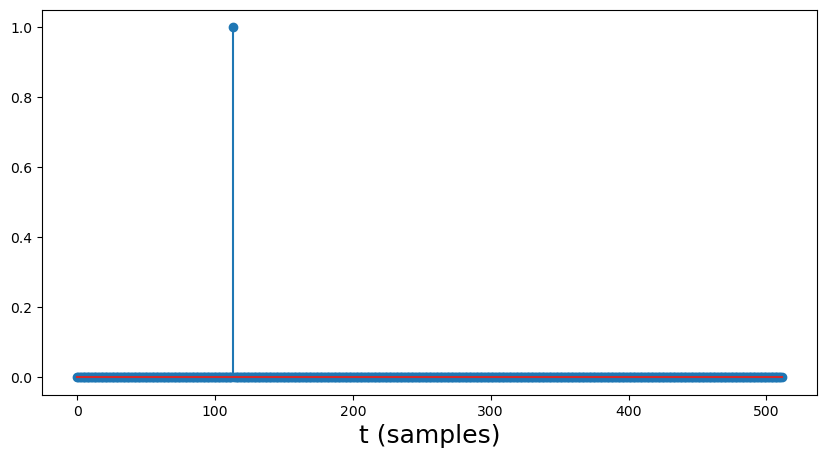

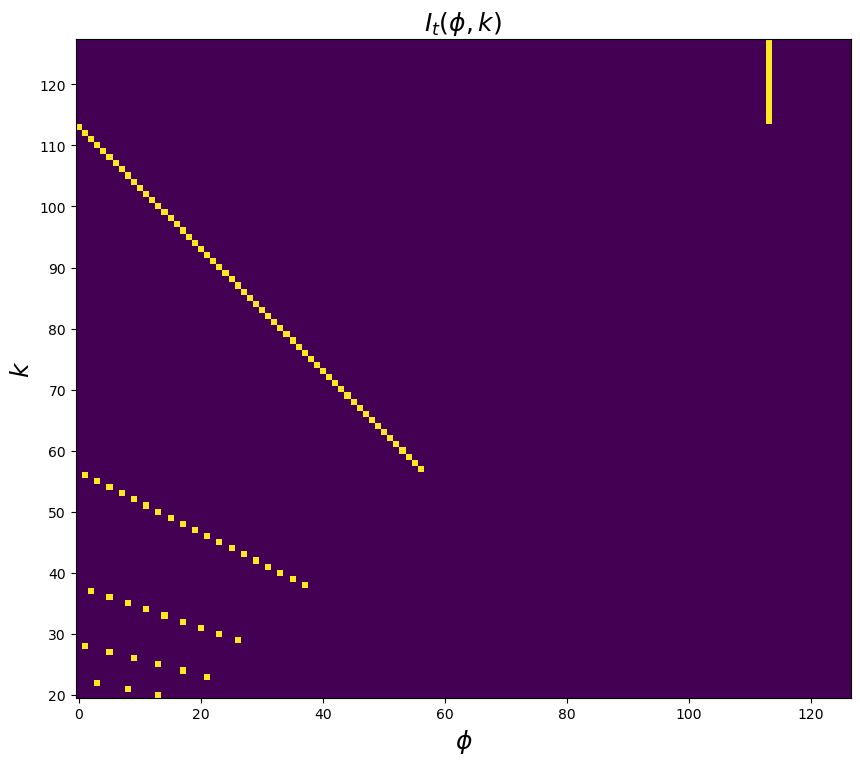

In [9]:
k_min = 20
k_max = 128
lags = np.arange(k_min, k_max)
t_hat = 113
N = 512
I = influence(t_hat, lags, N)

s = np.zeros(N)
s[t_hat] = 1

plt.figure(figsize=(10, 5))
plt.stem(s)
plt.xlabel('t (samples)', fontsize=18)

plt.figure(figsize=(10, 10))
plt.imshow(I, origin='lower')
plt.xlabel(r'$\phi$', fontsize=18)
plt.ylabel(r'$k$', fontsize=18)
plt.yticks(np.arange(0, k_max - k_min, 10), lag_interval[::10])
plt.title(r'$I_t(\phi, k)$', fontsize=18)
plt.show()

As can be seen, in the $(k,\phi)$ space, $\hat{t}$ influences only certain **segments** of $P(\phi, k)$, namely all the lines 


\begin{equation}
    k = -\frac{1}{i}\phi + \frac{\hat{t}}{i}
\end{equation}


with $i = \{0, 1, ..., K-1\}$. In particular, $i=0$ corresponds to the vertical line.
(Think to the equation of a line where $k$ is the $y$ and $\phi$ is the $x$).


This is a beam of lines with center $(k_0,\phi_0)$. Therefore, for each slope $i$, the following equation holds
\begin{equation}
    i k_0 = -\phi_0 + \hat{t} \quad  \forall i
\end{equation}

and the values for the center of the beam are:
\begin{equation}
    k_0 = 0\,,\\
    \phi_0 = \hat{t}\,.
\end{equation}


Such a beam of lines is shown in this figure:
<img src="data/img/influence.png" width="600px" align="center" alt="APM first example">


### Two Nonzero Points

We can now extend the previous considerations to the case of **two nonzero instants** $t_1, t_2$ in the input signal $\Delta(j)$.
The big difference is that now some entries of  $P(\phi, k)$ will be nonzero. 
For the reasons explained above, this will happen for all the values of $(\phi, k)$ belonging to the intersection of $\mathbf{I_{t1}}$ and $\mathbf{I_{t2}}$

\begin{equation}
\Big\{ (\phi, k) \in I_{t1} \cap I_{t2} \Big \}\,.
\end{equation}


This is true at the intersections of the two beams, one centered in $(t_1, 0)$ and the other in $(t_2, 0)$.
Let's visualize these two beams in the $\phi$-$k$ space:

<img src="data/img/influence_2.png" width="600px" align="center" alt="APM first example">



What happens to the APM?

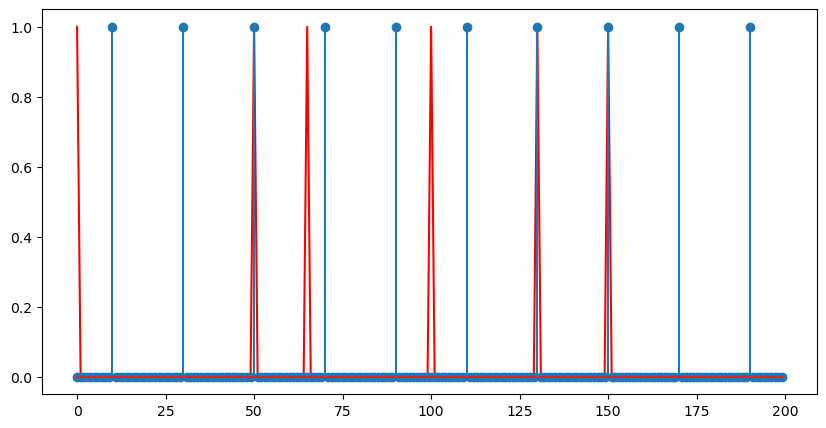

In [10]:
t0 = 0
t1 = 50 
t2 = 100
t3 = 150

t4 = 65 
t5 = 130

x = np.zeros(200)
x[t0] = 1
x[t1] = 1
x[t2] = 1
x[t3] = 1

x[t4] = 1
x[t5] = 1

plt.figure(figsize=(10,5))
plt.plot(x, color='red')

impulse_train = np.zeros(200)
# phi = 0
# k = 50, k = 65

phi = 10
k = 20
impulse_train[np.arange(phi, 200, k)] = 1
plt.stem(impulse_train)
plt.show()

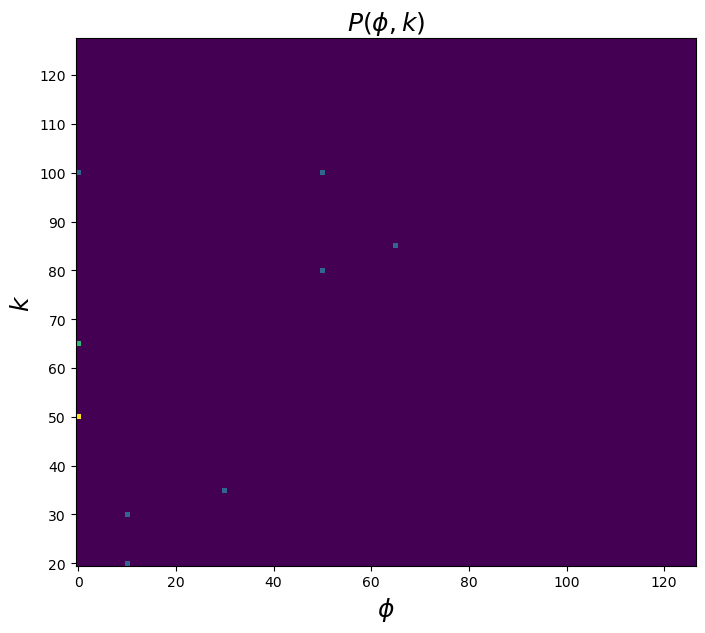

In [11]:
k_min = 20
k_max = 128
lags = np.arange(k_min, k_max)
P, C = compute_APM(x, lags)

plt.figure(figsize=(8, 8))
plt.imshow(P, origin='lower')
plt.xlabel(r'$\phi$', fontsize=18)
plt.ylabel(r'$k$', fontsize=18)
plt.yticks(np.arange(0, k_max - k_min, 10), lag_interval[::10])
plt.title(r'$P(\phi, k)$', fontsize=18)
plt.show()

As expected, in the autocorrelation matrix $P(\phi, k)$ only intersections where both coordinates are integer can be observed. In order to show all the intersections, we have to smooth the peaks at $t1$ and $t2$ and, to better show the lines in the beam, we are going to add a constant floor to the novelty function.

In [12]:
import scipy as sp

def smooth(x, smooth_win_length=11, smooth_win_type='boxcar'):
    
    if x.ndim != 1:
        raise ValueError('smooth only accepts 1 dimension arrays.')

    if x.size < smooth_win_length:
        raise ValueError('Input vector needs to be bigger than window size.')

    if smooth_win_length<3:
        return x
    
    # mirror pad
    s = np.pad(x, int(smooth_win_length/2), mode='reflect')    
    # create window
    w = sp.signal.windows.get_window(smooth_win_type, smooth_win_length)
    # convolve with normalized window
    w_normalised = w / w.sum()
    y = np.convolve(s, w_normalised, mode='same')
    
    return y

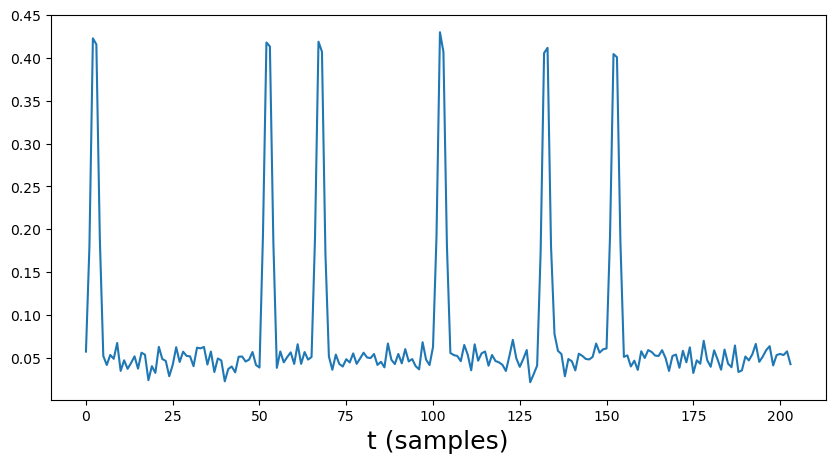

In [13]:
# add positive random noise for showing all the lines
smooth_x = smooth(x, smooth_win_length = 5, smooth_win_type='hann')
noise = 0.05 + 0.01 * np.random.randn(len(smooth_x))

noise[noise < 0] = 0

smooth_x = smooth_x + noise

plt.figure(figsize=(10, 5))
plt.plot(smooth_x)
plt.xlabel('t (samples)', fontsize=18)
plt.show()

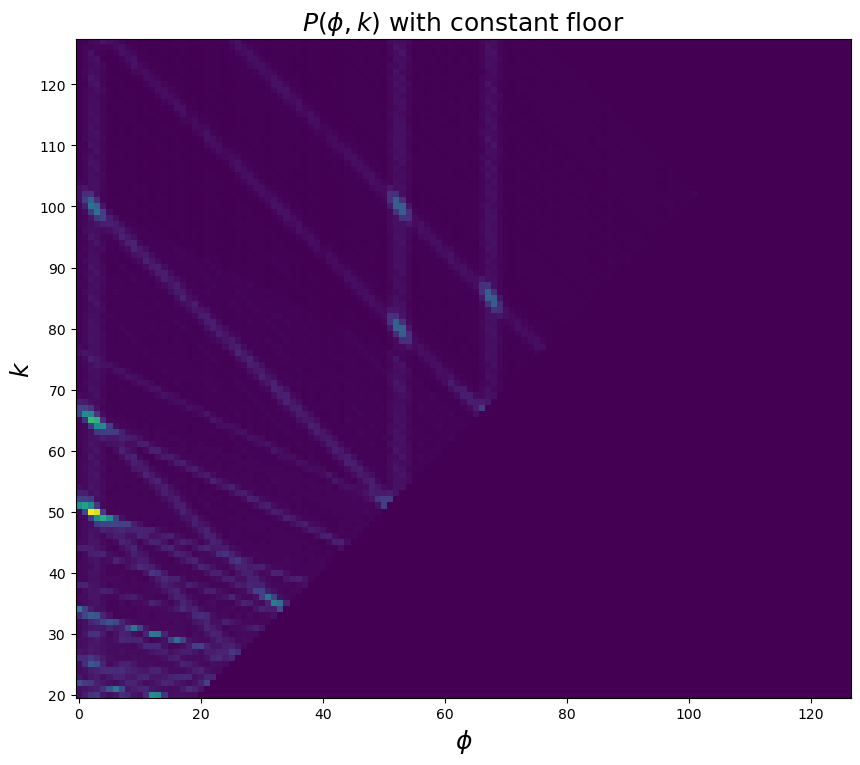

In [14]:
import matplotlib
k_min = 20
k_max = 128
lags = np.arange(k_min, k_max)
P, C = compute_APM(smooth_x, lags)


plt.figure(figsize=(10,10))
plt.imshow(P,  origin='lower')
plt.xlabel(r'$\phi$', fontsize=18)
plt.ylabel(r'$k$', fontsize=18)
plt.yticks(np.arange(0, k_max - k_min, 10), lag_interval[::10])
plt.title(r'$P(\phi, k)$ with constant floor', fontsize=18)

plt.show()

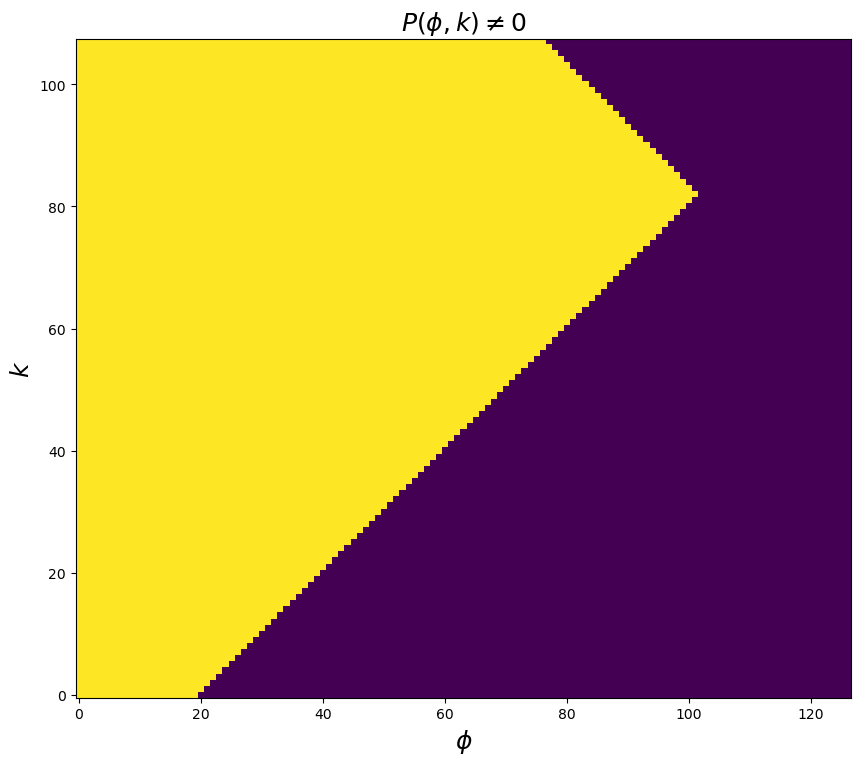

In [15]:
plt.figure(figsize=(10,10))
plt.imshow((P!=0), origin="lower")
plt.xlabel(r'$\phi$', fontsize=18)
plt.ylabel(r'$k$', fontsize=18)
plt.title(r'$P(\phi, k) \neq 0$', fontsize=18)
plt.show()